# Predicting Hospital Cost and Emergency Admissions Using Machine Learning

**Allison Evanich**  

## Project Overview
This project explores two healthcare machine learning tasks using a synthetic hospital admissions dataset:

1. **Predicting high-cost hospital admissions**
2. **Predicting emergency vs. non-emergency admissions**

A key goal of the project was not only to build predictive models, but also to evaluate model validity, detect target leakage, and interpret model limitations responsibly.

## Business Problem

Healthcare organizations often want to predict costly admissions and emergency utilization to improve resource planning, staffing, and operational efficiency. This project evaluates whether demographic, administrative, and limited clinical variables can support those prediction tasks.

The analysis also demonstrates an important applied data science lesson: **strong performance metrics are not meaningful if the model is invalid due to target leakage**.

## Dataset

The dataset used in this project is a **synthetic healthcare dataset from Kaggle**.  
It includes variables such as:

- Age
- Gender
- Blood Type
- Medical Condition
- Date of Admission
- Hospital
- Insurance Provider
- Billing Amount
- Admission Type
- Discharge Date
- Medication
- Test Results

Because the data is synthetic, it is useful for experimentation while avoiding protected health information concerns.

In [13]:
# 1) SETUP & IMPORTS

import zipfile
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [14]:
# 2) LOAD DATA

df = pd.read_csv(r'healthcare_dataset.csv')
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## Data Preparation and Feature Engineering

The following preprocessing steps were used:

- Convert admission and discharge dates to datetime format
- Calculate **length of stay (LOS)**
- Create a binary **HighBilling** target based on the top 25% of billing amounts
- Create a binary **EmergencyAdmission** target for emergency vs non-emergency admissions
- Create age group categories for exploratory analysis

In [16]:
# 3) FEATURE ENGINEERING

# 1) Parse dates
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])

# 2) Length of stay (LOS)
df["LOS"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days
df.loc[df["LOS"] < 0, "LOS"] = np.nan  # safety

# 3) HighBilling (top 25% by Billing Amount)
billing_75 = df["Billing Amount"].quantile(0.75)
df["HighBilling"] = (df["Billing Amount"] > billing_75).astype(int)

# 4) AgeGroup (optional)
age_bins = [0, 18, 35, 50, 65, 120]
age_labels = ["0-17", "18-34", "35-49", "50-64", "65+"]
df["AgeGroup"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels, right=True)

# Quick sanity check
df[["Billing Amount", "HighBilling", "LOS", "Age", "AgeGroup"]].head(), df["HighBilling"].value_counts(normalize=True)

(   Billing Amount  HighBilling   LOS  Age AgeGroup
 0    18856.281306            0   2.0   30    18-34
 1    33643.327287            0   6.0   62    50-64
 2    27955.096079            0  15.0   76      65+
 3    37909.782410            1  30.0   28    18-34
 4    14238.317814            0  20.0   43    35-49,
 HighBilling
 0    0.75
 1    0.25
 Name: proportion, dtype: float64)

## Exploratory Visualization: Billing Distribution

This figure shows the distribution of billing amounts and supports the definition of the **HighBilling** target using the 75th percentile threshold.

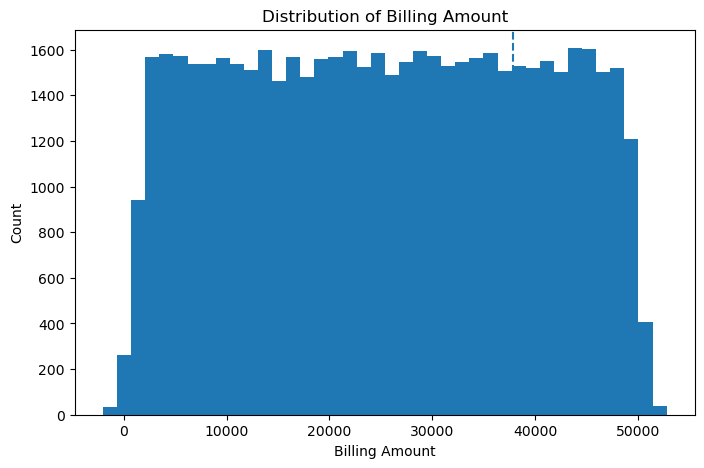

In [18]:
# 4) VISUAL 1: BILLING DISTRIBUTION

plt.figure(figsize=(8,5))
plt.hist(df["Billing Amount"], bins=40)
plt.axvline(billing_75, linestyle="--")
plt.title("Distribution of Billing Amount")
plt.xlabel("Billing Amount")
plt.ylabel("Count")
plt.show()

## Modeling Task 1: Predicting High-Billing Admissions

The initial modeling task attempted to predict whether an admission belonged to the top 25% of billing amounts.

### Important note
The first version of this model intentionally recreates the original **leaky model** to demonstrate how target leakage caused unrealistically perfect performance.

### Leaky HighBilling Model

In the initial version of the model, the feature set included:

- `Billing Amount`
- `LOS`

Because `Billing Amount` was also used to define the target variable `HighBilling`, this created **target leakage**.

In [21]:
# 5) LEAKY MODEL: HighBilling

y_hb = df["HighBilling"]

X_leaky = df.drop(columns=[
    "HighBilling",
    "Name",
    "Date of Admission",
    "Discharge Date",
    "Doctor",
    "Room Number"
])

numeric_leaky = ["Age", "LOS", "Billing Amount"]
categorical_leaky = [c for c in X_leaky.columns if c not in numeric_leaky]

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_leaky, y_hb, test_size=0.2, random_state=42, stratify=y_hb
)

preprocessor_leaky = ColumnTransformer([
    ("num", StandardScaler(), numeric_leaky),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_leaky)
])

leaky_model = Pipeline([
    ("prep", preprocessor_leaky),
    ("rf", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

leaky_model.fit(X_train_l, y_train_l)

y_proba_leaky = leaky_model.predict_proba(X_test_l)[:, 1]
print("Leaky HighBilling ROC-AUC:", roc_auc_score(y_test_l, y_proba_leaky))

Leaky HighBilling ROC-AUC: 1.0


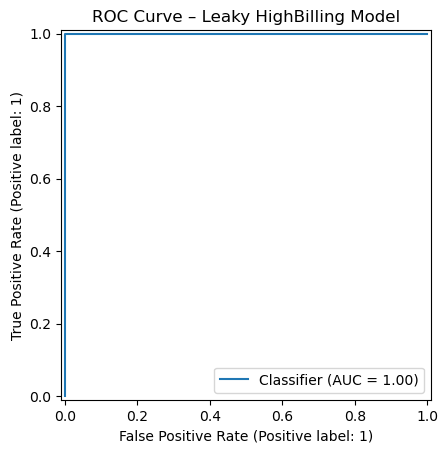

In [22]:
# 6) VISUAL 2: ROC CURVE – LEAKY HighBilling

RocCurveDisplay.from_predictions(y_test_l, y_proba_leaky)
plt.title("ROC Curve – Leaky HighBilling Model")
plt.show()

### Feature Importance: Leakage Diagnosis

Feature importance was used to confirm whether one variable was dominating the predictions.

In [24]:
# 7) FEATURE IMPORTANCE TABLE for LEAKY MODEL

cat_encoder = leaky_model.named_steps["prep"].named_transformers_["cat"]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_leaky)

all_feature_names = np.concatenate([numeric_leaky, cat_feature_names])
importances = leaky_model.named_steps["rf"].feature_importances_

feature_importances = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importances.head(15)

,feature,importance
2,Billing Amount,0.933093
0,Age,0.000794
1,LOS,0.000785
33298,Test Results_Inconclusive,0.000198
33290,Admission Type_Emergency,0.000178
33289,Admission Type_Elective,0.000178
3,Gender_Female,0.000174
33299,Test Results_Normal,0.000172
33294,Medication_Lipitor,0.000171
33297,Test Results_Abnormal,0.000163


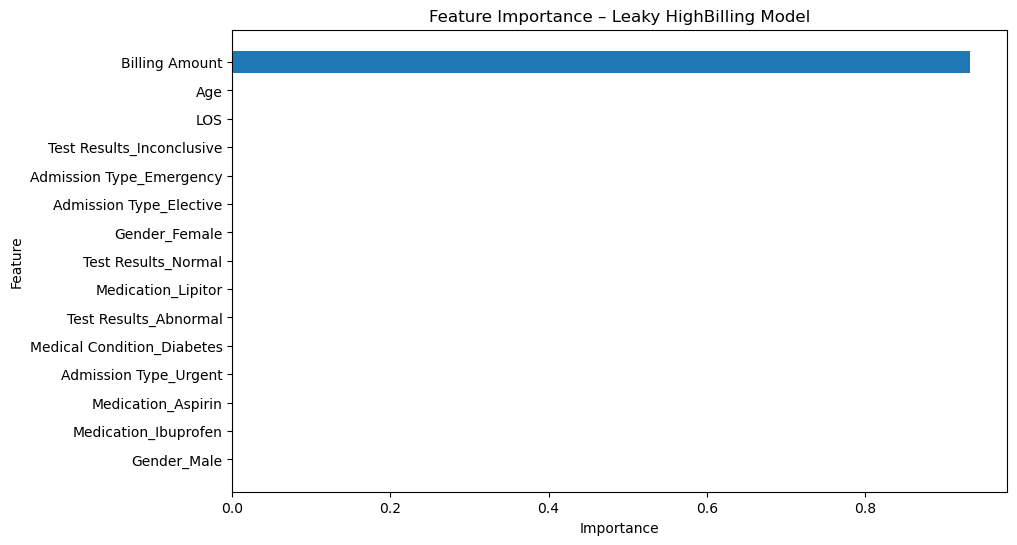

In [25]:
# 8) VISUAL 4: FEATURE IMPORTANCE – LEAKY HighBilling

top = feature_importances.head(15)

plt.figure(figsize=(10,6))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.title("Feature Importance – Leaky HighBilling Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Interpretation of the Leaky Model

The initial HighBilling model produced near-perfect results because **Billing Amount** was included as a predictor even though it defined the target variable. This is a classic case of **target leakage**.

This result is misleading because the model is not learning generalizable patterns. Instead, it is effectively being given the answer.

## Corrected HighBilling Model

To correct for leakage, the following variables were removed:

- `Billing Amount`
- `LOS`
- other post-admission variables

A faster Random Forest version was used for computational efficiency, and `Hospital` was excluded because it produced a very large number of encoded columns.

In [28]:
# 9) CORRECTED MODEL: HighBilling 

X_corr = df.drop(columns=[
    "HighBilling", "Name", "Date of Admission", "Discharge Date",
    "Doctor", "Room Number", "Billing Amount", "LOS",
    "Hospital"   # drop high-cardinality for speed
])

numeric_corr = ["Age"]
categorical_corr = [c for c in X_corr.columns if c not in numeric_corr]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_corr, y_hb, test_size=0.2, random_state=42, stratify=y_hb
)

preprocessor_corr = ColumnTransformer([
    ("num", StandardScaler(), numeric_corr),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_corr)
])

corrected_model = Pipeline([
    ("prep", preprocessor_corr),
    ("rf", RandomForestClassifier(
        n_estimators=80,
        max_depth=12,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=42
    ))
])

corrected_model.fit(X_train_c, y_train_c)

y_proba_corrected = corrected_model.predict_proba(X_test_c)[:, 1]
print("Corrected HighBilling ROC-AUC:", roc_auc_score(y_test_c, y_proba_corrected))

Corrected HighBilling ROC-AUC: 0.5389679842004167


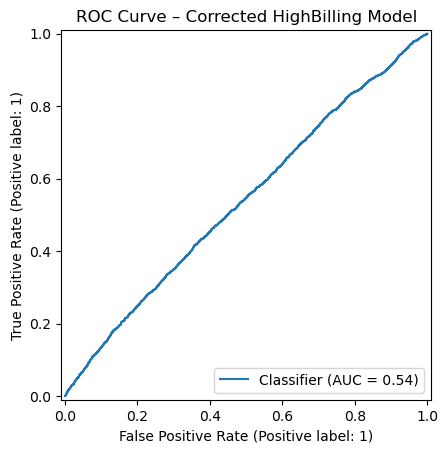

In [29]:
# 10) VISUAL 3: ROC CURVE – CORRECTED HighBilling

RocCurveDisplay.from_predictions(y_test_c, y_proba_corrected)
plt.title("ROC Curve – Corrected HighBilling Model")
plt.show()

## Interpretation of the Corrected HighBilling Model

After removing leakage variables, the corrected model’s ROC-AUC dropped to approximately **0.50**, indicating near-random discrimination.

This suggests that the remaining demographic and administrative variables were **insufficient to predict high-cost admissions** in this dataset. In real healthcare environments, better cost prediction would likely require:

- procedure codes
- diagnosis detail
- imaging and lab utilization
- ICU admissions
- treatment intensity
- severity indicators

## Modeling Task 2: Predicting Emergency Admissions

A second modeling task attempted to predict whether an admission was classified as **emergency vs. non-emergency**.

As with the cost model, careful feature selection was necessary to avoid leakage. `Admission Type` was removed from the predictors because it directly defines the target.


In [32]:
# 11) EMERGENCY ADMISSION MODEL

df["EmergencyAdmission"] = (df["Admission Type"] == "Emergency").astype(int)
y_em = df["EmergencyAdmission"]

X_em = df.drop(columns=[
    "EmergencyAdmission",
    "Admission Type",      # remove to prevent leakage
    "HighBilling",
    "Billing Amount",
    "LOS",
    "Name",
    "Date of Admission",
    "Discharge Date",
    "Doctor",
    "Room Number"
])

numeric_em = ["Age"]
categorical_em = [c for c in X_em.columns if c not in numeric_em]

X_train_em, X_test_em, y_train_em, y_test_em = train_test_split(
    X_em, y_em, test_size=0.2, random_state=42, stratify=y_em
)

preprocessor_em = ColumnTransformer([
    ("num", StandardScaler(), numeric_em),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_em)
])

emergency_model = Pipeline([
    ("prep", preprocessor_em),
    ("rf", RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

emergency_model.fit(X_train_em, y_train_em)

y_pred_em = emergency_model.predict(X_test_em)
y_proba_em = emergency_model.predict_proba(X_test_em)[:, 1]

print("EmergencyAdmission ROC-AUC:", roc_auc_score(y_test_em, y_proba_em))
print(classification_report(y_test_em, y_pred_em))

EmergencyAdmission ROC-AUC: 0.5009985965729387
              precision    recall  f1-score   support

           0       0.67      0.97      0.79      7446
           1       0.31      0.03      0.05      3654

    accuracy                           0.66     11100
   macro avg       0.49      0.50      0.42     11100
weighted avg       0.55      0.66      0.55     11100



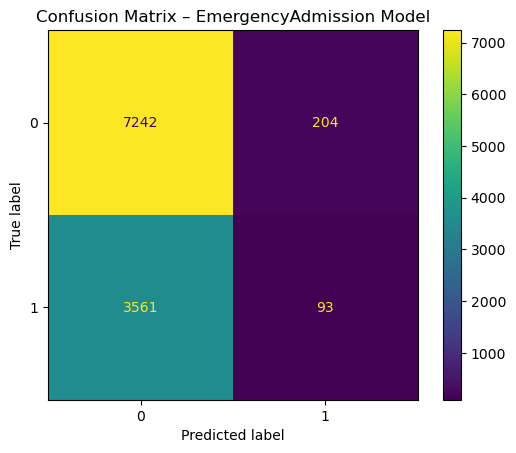

In [33]:
# 12) VISUAL 5: CONFUSION MATRIX – EmergencyAdmission

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test_em, y_pred_em)
plt.title("Confusion Matrix – EmergencyAdmission Model")
plt.show()

## Interpretation of the EmergencyAdmission Model

The final emergency admission model achieved approximately:

- **Accuracy ≈ 0.66**
- **ROC-AUC ≈ 0.50**

The confusion matrix showed that the model predicted **non-emergency admissions much better than emergency admissions**, resulting in very low recall for the emergency class.

This indicates that the dataset lacks important triage-related variables such as:

- acuity scores
- vital signs
- presenting symptoms
- clinician assessment data

## Ethical Considerations

This project highlights several important ethical lessons for healthcare machine learning:

- **Target leakage** can produce misleading results and false confidence
- Poorly validated models can be harmful if used in real healthcare settings
- Model interpretability is especially important in healthcare because predictions may affect patient care and resource allocation
- Data quality and feature relevance are just as important as algorithm choice

## Conclusion

This project demonstrates an applied machine learning workflow focused on:

- feature engineering
- leakage detection
- ROC-based evaluation
- honest interpretation of model limitations

Although the final corrected models did not achieve strong predictive performance, the project provides an important lesson in **responsible healthcare analytics**. Strong performance metrics are not enough; models must also be valid, interpretable, and aligned with the available data.